# Imports and load data

In [4]:
from pathlib import Path 
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch 

In [5]:
RESULTS_PATH = Path("../results")
SUBSAMPLED_TESTF1_PATH  = RESULTS_PATH / "testf1_subsampling.csv"
FULL_TESTF1_PATH  = RESULTS_PATH / "testf1_full.csv"

df = pd.read_csv(SUBSAMPLED_TESTF1_PATH)
df_full = pd.read_csv(FULL_TESTF1_PATH)

# Definitions and Functions

In [ ]:
# definitions
fams = ['5s', 'tRNA',  'tmRNA',   'RNaseP','srp',  'telomerase', 'grp1', '23s', '16s']
fam_map = {f: i for i, f in enumerate(fams)}
models = df_full["model"].unique()

PALETTE = {100: "#1B9E77", 200: "#D95F02", 400: "#7570B3"}
MARKERS = {"randS": "o", "sortS": "^", "clusS": "*"}

sns.set_style("whitegrid")

In [7]:
def strip(ax, df, fam_map):
    delta = 0.25
    ds = 3*delta / len(df.groupby("strategy")) if len(df.groupby("strategy")) != 0 else 0
    x = df["fam"].map(fam_map) - delta
    # plot
    for strategy, g in df.groupby("strategy"):
        ax.scatter(
            x[g.index],
            g["test_f1"],
            marker=MARKERS[strategy],
            c=[PALETTE[u] for u in g["K"]],
            edgecolors="k",
            lw=0.5,
            s=60,
            alpha=0.75,
            label=strategy,
        )
        x += ds  # move x to the next strategy

def plot_f1(ax, df, model, fam_map):
  sns.barplot(
        data=df_full[df_full["model"] == model],
        x="fam",
        y="test_f1",
        order=fams,
        color="gray",
        alpha=0.4,
        errorbar=None,
        ax=ax,
    )
  strip(ax, df[df["model"] == model], fam_map)

  ax.set_ylim(0, 0.95)
  ax.set_title(model, fontsize=14, fontweight="bold")
  ax.set_xlabel("")
  ax.set_xticks(range(len(fams)))
  ax.set_xticklabels(fams, fontsize=10, rotation=45)
  if ax.get_legend():
      ax.get_legend().remove()

##################################################

def filter_df(df, strategy, K):

  if strategy == "all" and K == "all":
    return df.copy()
  elif strategy == "all":
    return df[df["K"] == K].copy()
  elif K == "all":
    return df[df["strategy"] == strategy].copy()
  else:
    return df[(df["strategy"] == strategy) & (df["K"] == K)].copy()

def plot_results(df, models, fam_map, axes, strategy="all", K="all"):
  df = filter_df(df, strategy, K)
  for ax, model in zip(axes, models):
      plot_f1(ax, df, model, fam_map)
  axes[0].set_ylabel("F1 Score", fontsize=12)

  # Legend
  h_baseline = [Patch(color="gray", alpha=0.4, label="Baseline")]

  # strategy
  h_shapes = [Line2D(
          [], [], color="black", marker=marker,
          linestyle="", markersize=9, label=name
      ) for name, marker in MARKERS.items()
  ]
  # K
  h_colors = [Line2D(
          [], [], color=color, marker="D",
          linestyle="", markersize=9, label=str(thr)
      ) for thr, color in PALETTE.items()
  ]

  fig.legend(
      handles=h_baseline + h_shapes + h_colors,
      loc="lower center",
      bbox_to_anchor=(0.5, -0.01),
      ncol=7,
      frameon=False,
      fontsize=12,
  )

  plt.subplots_adjust(
      left=0.05,
      right=0.99,
      top=0.88,
      bottom=0.25,
      wspace=0.05,
  )


# Visualize F1 scores

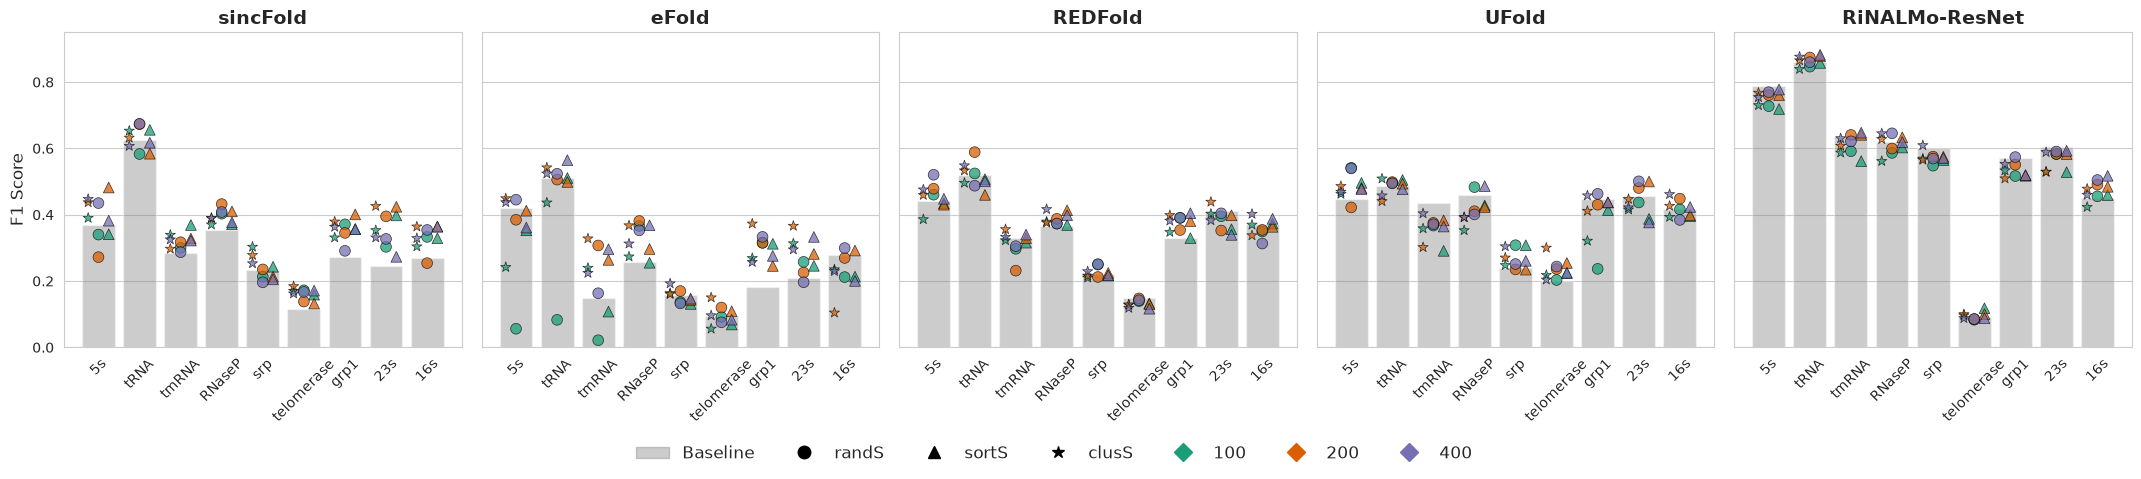

In [8]:
#@title Visualize F1 scores given a strategy and the subsampled value (K) { run: "auto" }
#@markdown Select the strategy and K.

#@markdown ---
strategy = 'all'   #@param ["all", "randS", "sortS", "clusS"]
K = "all"          #@param ["all", 400, 200, 100]
#@markdown ---

K = K if K == "all" else int(K)
fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=True)
plot_results(df, models, fam_map, axes, strategy=strategy, K=K)
plt.show()